In [1]:
from qiskit.quantum_info import SparsePauliOp
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import ParameterVector
from qiskit_ibm_runtime import SamplerV2, EstimatorV2
from qiskit_aer import AerSimulator

from qiskit.circuit.library import PauliEvolutionGate
from scipy.optimize import minimize
from contextlib import redirect_stderr

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import time
import os
import sys

np.random.seed(42)

In [1]:
class TSPQAOA:
    def __init__(self, W, n_layers=1):
        self.W = W
        self.N = len(W)
        self.n_qubits = self.N ** 2
        self.n_layers = n_layers
        self.debug_mode = False

        self.backend = AerSimulator(
            method='matrix_product_state',
            device='CPU'
        ) 
        self.sampler = SamplerV2(mode=self.backend)
        
        # Parâmetros e Operadores
        self.H = self._build_cost_hamiltonian()
        self.gamma = ParameterVector("γ", n_layers)
        self.beta = ParameterVector("β", n_layers)
        
        # Circuito Base (Transpilado uma única vez para performance)
        self.qc_t = self._build_base_circuit()

    def _idx(self, i, p):
        """Mapeia cidade i e posição p para o índice do qubit."""
        return i * self.N + p
    
    def _build_cost_hamiltonian(self):
        """Cria o Hamiltoniano de custo baseado na matriz W."""
        paulis = []
        coeffs = []
        for i in range(self.N):
            for j in range(self.N):
                if i != j:
                    for p in range(self.N):
                        q1 = self._idx(i, p)
                        q2 = self._idx(j, (p + 1) % self.N)
                        w = self.W[i, j]
                        
                        # Termos lineares e quadráticos da expansão (1-Z1)(1-Z2)/4
                        for indices, weight in [([q1], -w/4), ([q2], -w/4), ([q1, q2], w/4)]:
                            label = ["I"] * self.n_qubits
                            for idx in indices:
                                label[idx] = "Z"
                            paulis.append("".join(label))
                            coeffs.append(weight)
                            
        return SparsePauliOp(paulis, coeffs).simplify()

    def _apply_xy_mixer(self, qc, beta_val):
        """Aplica o Mixer XY que preserva o peso de Hamming."""
        # Trocas entre cidades para a mesma posição
        for p in range(self.N):
            for i in range(self.N):
                for j in range(i + 1, self.N):
                    q1, q2 = self._idx(i, p), self._idx(j, p)
                    qc.rxx(2 * beta_val, q1, q2)
                    qc.ryy(2 * beta_val, q1, q2)
        
        # Trocas entre posições para a mesma cidade
        for i in range(self.N):
            for p in range(self.N):
                for q in range(p + 1, self.N):
                    q1, q2 = self._idx(i, p), self._idx(i, q)
                    qc.rxx(2 * beta_val, q1, q2)
                    qc.ryy(2 * beta_val, q1, q2)

    def _build_base_circuit(self):
        """Constrói o esqueleto do circuito QAOA."""
        qc = QuantumCircuit(self.n_qubits)
        
        # Estado Inicial: Uma cidade em cada posição (Matriz Identidade)
        # IMPORTANTE: retirei a superposição para focar somente na permutação entre cidade/posição
        for i in range(self.N):
            qc.x(self._idx(i, i))
            
        for l in range(self.n_layers):
            # Evolução do Custo
            evo_gate = PauliEvolutionGate(self.H, time=self.gamma[l])
            qc.append(evo_gate, range(self.n_qubits))
            
            # Mixer XY
            self._apply_xy_mixer(qc, self.beta[l])
            
        return transpile(qc, self.backend)

    def _cost_function(self, params, estimator):
        """Função interna para o otimizador clássico."""
        middle = len(params) // 2

        bound = self.qc_t.assign_parameters({
            self.gamma: params[:middle], 
            self.beta: params[middle:]
        })

        job = estimator.run([(bound, self.H)])
        evs = job.result()[0].data.evs
        if self.debug_mode:
            print(evs)
        return evs

    def debug(self, debug_mode):
        self.debug_mode = debug_mode
    
    def solve(self, max_iter=500):
        """Executa a otimização e retorna os resultados."""
        estimator = EstimatorV2(mode=self.backend)
        
        # Inicialização dos parâmetros
        init_params = np.concatenate([
            np.linspace(0.01, 0.2, self.n_layers),
            np.linspace(0.01, 0.01, self.n_layers)
        ])
        
        answer = minimize(
            self._cost_function, 
            init_params, 
            args=(estimator), 
            method="COBYLA", 
            options={'maxiter': max_iter}
        )
        
        return answer

    def get_counts(self, optimal_params, shots=10000):
        """Gera a amostragem final com os parâmetros ótimos."""
        final_qc = self.qc_t.assign_parameters({
            self.gamma: optimal_params[:self.n_layers], 
            self.beta: optimal_params[self.n_layers:]
        })
        final_qc.measure_all()
        
        job = self.sampler.run([final_qc], shots=shots)
        return job.result()[0].data.meas.get_counts()
    
    def analyze_routes(self, counts, top_k=10):
        """Processa os bitstrings, extrai rotas e calcula a distância total."""
        sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)[:top_k]
        resultados = []

        for bitstring, freq in sorted_counts:
            bits = bitstring[::-1]
            matriz = []
            for p in range(self.N):
                linha = [int(bits[self._idx(i, p)]) for i in range(self.N)]
                matriz.append(linha)

            # Validação das restrições
            valido = True
            # 1) Cada posição (linha da matriz) deve ter exatamente uma cidade
            for p in range(self.N):
                if sum(matriz[p]) != 1:
                    valido = False; break
            
            # 2) Cada cidade (coluna da matriz) deve aparecer exatamente uma vez
            if valido:
                for i in range(self.N):
                    coluna = [matriz[p][i] for p in range(self.N)]
                    if sum(coluna) != 1:
                        valido = False; break

            rota = None
            distancia = None

            if valido:
                # Extrair a ordem das cidades
                rota = [row.index(1) for row in matriz]
                
                # Calcular distância total (Ciclo Hamiltoniano)
                distancia = 0
                for step in range(self.N):
                    cidade_atual = rota[step]
                    proxima_cidade = rota[(step + 1) % self.N] # %N fecha o ciclo
                    distancia += self.W[cidade_atual, proxima_cidade]

            resultados.append({
                "bitstring": bitstring,
                "frequencia": freq,
                "valido": valido,
                "rota": rota,
                "distancia": distancia
            })
            
        return resultados

In [3]:
def format(ns):
  horas = ns // (3600 * 10**9)
  minutos = (ns // (60 * 10**9)) % 60
  segundos = (ns // 10**9) % 60
  milissegundos = (ns // 10**6) % 1000
  nanosegundos = ns % 10**6

  return f"{horas}h {minutos}m {segundos}s {milissegundos}ms {nanosegundos}ns"

def brute_force_tsp(w):
    from itertools import permutations

    N = len(w)
    a = list(permutations(range(1, N)))
    last_best_distance = 1e10
    for i in a:
        distance = 0
        pre_j = 0
        for j in i:
            distance = distance + w[j, pre_j]
            pre_j = j
        distance = distance + w[pre_j, 0]
        order = (0,) + i
        if distance < last_best_distance:
            best_order = order
            last_best_distance = distance
    return last_best_distance, best_order

def run_silent_qaoa(solver, iterations):
    with open(os.devnull, 'w') as fnull:
        with redirect_stderr(fnull):
            # Tenta executar o solve sem deixar o C++ escrever na tela
            return solver.solve(max_iter=iterations)

In [ ]:
if __name__ == "__main__":
    samples = (
        np.array([[0, 1, 4], [1, 0, 2], [4, 2, 0]]),
        np.array([[0, 1, 4, 3], [1, 0, 2, 2], [4, 2, 0, 5], [3, 2, 5, 0]]),
        np.array([[0, 1,  4, 3,  7], [1, 0,  2, 2, 10], [4, 2,  0, 5,  8], [3, 2,  5, 0,  6], [7, 10, 8, 6,  0]]),
        np.array([[0, 5, 8, 4, 5, 6], [5, 0, 4, 7, 5, 4], [8, 4, 0, 5, 6, 4], [4, 7, 5, 0, 4, 8], [5, 5, 6, 4, 0, 5], [6, 4, 4, 8, 5, 0]]),
        np.array([[0, 6, 8, 5, 7, 6, 9], [6, 0, 5, 7, 6, 5, 8], [8, 5, 0, 6, 8, 5, 7], [5, 7, 6, 0, 5, 9, 6], [7, 6, 8, 5, 0, 6, 5], [6, 5, 5, 9, 6, 0, 7], [9, 8, 7, 6, 5, 7, 0]])
    )

    print('algorithm;vertex;layers;bitstring;rota;distancia;frequencia;status;time_solver;desc_solver;time_optimization;desc_optimization')
    for W in samples:
        start = time.perf_counter_ns()
        distance, route = brute_force_tsp(W)
        time_solver = time.perf_counter_ns() - start 

        print(f'BF;{len(W)};None;None;{list(route)};{distance};None;Válida;{time_solver};{format(time_solver)};None;None')
        
        for n_layer in [1, 2, 3, 4, 5, 6]:
            try:
                solver = TSPQAOA(W, n_layers=n_layer)
                #solver.debug(True)
                
                start = time.perf_counter_ns()
                result = run_silent_qaoa(solver, iterations=500)
                time_solver = time.perf_counter_ns() - start 

                start = time.perf_counter_ns()
                counts = solver.get_counts(result.x)
                time_optimization = time.perf_counter_ns() - start 

                for x in solver.analyze_routes(counts, 10):
                    status = "Válida" if x['valido'] else "Inválida"
                    print(f'QAOA;{len(W)};{n_layer};{x['bitstring']};{x['rota']};{x['distancia']};{x['frequencia']};{status};{time_solver};{format(time_solver)};{time_optimization};{format(time_optimization)}')
            except Exception as e:
                print(f'QAOA;{len(W)};{n_layer};None;None;None;None;{str(e)};None;None;None;None')


algorithm;vertex;layers;bitstring;rota;distancia;frequencia;status;time_solver;desc_solver;time_optimization;desc_optimization
BF;3;None;None;[0, 1, 2];7;None;Válida;115100;0h 0m 0s 0ms 115100ns;None;None
QAOA;3;1;010100001;[0, 2, 1];7;518;Válida;4819403600;0h 0m 4s 819ms 403600ns;293236800;0h 0m 0s 293ms 236800ns
QAOA;3;1;001010100;[2, 1, 0];7;445;Válida;4819403600;0h 0m 4s 819ms 403600ns;293236800;0h 0m 0s 293ms 236800ns
QAOA;3;1;100001010;[1, 0, 2];7;428;Válida;4819403600;0h 0m 4s 819ms 403600ns;293236800;0h 0m 0s 293ms 236800ns
QAOA;3;1;111000000;None;None;362;Inválida;4819403600;0h 0m 4s 819ms 403600ns;293236800;0h 0m 0s 293ms 236800ns
QAOA;3;1;000111000;None;None;343;Inválida;4819403600;0h 0m 4s 819ms 403600ns;293236800;0h 0m 0s 293ms 236800ns
QAOA;3;1;000000111;None;None;331;Inválida;4819403600;0h 0m 4s 819ms 403600ns;293236800;0h 0m 0s 293ms 236800ns
QAOA;3;1;110000001;None;None;217;Inválida;4819403600;0h 0m 4s 819ms 403600ns;293236800;0h 0m 0s 293ms 236800ns
QAOA;3;1;000110001

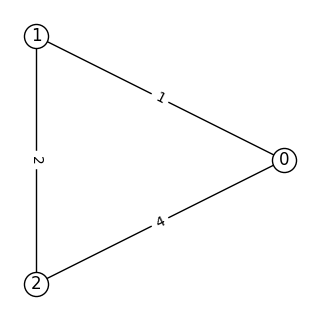

In [27]:
def draw_graph(G):
    plt.figure(figsize=(3, 3))

    layout = nx.circular_layout(G)
    nx.draw(G, layout, 
            with_labels=True, 
            node_color='white', 
            edgecolors='black') # edgecolors mantém a borda visível se desejar
    
    labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos=layout, edge_labels=labels)
    plt.show()

G = nx.from_numpy_array(W)

draw_graph(G)